In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


## Count Images per Class in Train / Validation / Test


In [ ]:
DATASET_DIR = "dataset"   

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

selected_classes = [
    "Apple",
    "Banana",
    "Bell Pepper",
    "Carrot",
    "Grapes",
    "Kiwi",
    "Lemon",
    "Orange",
    "Pear",
    "Tomato"
]

# =========================
# 3. Function to count images
# =========================

def count_images_in_class(folder_path, class_name):
    class_path = os.path.join(folder_path, class_name)

    if not os.path.exists(class_path):
        print(f"Warning: Folder not found -> {class_path}")
        return 0

    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ])

    return image_count

# =========================
# 4. Count images for each split
# =========================

data = []

for class_name in selected_classes:
    train_count = count_images_in_class(TRAIN_DIR, class_name)
    val_count = count_images_in_class(VAL_DIR, class_name)
    test_count = count_images_in_class(TEST_DIR, class_name)

    data.append({
        "Class": class_name,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
    })

df_counts = pd.DataFrame(data)

# Display table
df_counts

,Class,Train,Validation,Test,Total
0,Apple,68,10,10,88
1,Banana,75,9,9,93
2,Bell Pepper,90,9,10,109
3,Carrot,82,9,10,101
4,Grapes,100,9,10,119
5,Kiwi,88,10,10,108
6,Lemon,82,10,10,102
7,Orange,69,9,10,88
8,Pear,89,10,10,109
9,Tomato,92,10,10,112


## Plot class distribution

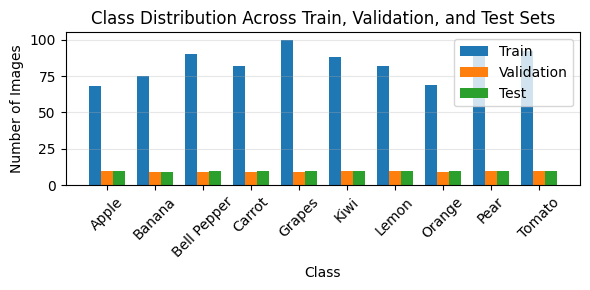

In [6]:
plt.figure(figsize=(6,3))

x = range(len(df_counts["Class"]))

plt.bar([i - 0.25 for i in x], df_counts["Train"], width=0.25, label="Train")
plt.bar(x, df_counts["Validation"], width=0.25, label="Validation")
plt.bar([i + 0.25 for i in x], df_counts["Test"], width=0.25, label="Test")

plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, df_counts["Class"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

A grouped bar chart was created to compare the class distribution across the three splits. This helps identify whether the dataset is balanced or imbalanced.

If the number of samples is similar across classes, accuracy can be a reasonable evaluation metric. However, if some classes have many more images than others, accuracy may become misleading.